# Task #2c — Data Profiling: `habsos_cellcounts`

**Issue:** [Break-Through-Tech/Biointerphase-1C-forecasting-harmful-algal-bloom-risk#5](https://github.com/Break-Through-Tech/Biointerphase-1C-forecasting-harmful-algal-bloom-risk/issues/5)

**Goal:** Profile `habsos_cellcounts` to get a high-level overview — row counts, numeric vs. categorical columns, missing values, duplicates, invalid values, and outliers — and propose a handling strategy for each issue found.

**Deliverable:** Short data-quality summary + proposed handling strategy (see the summary section at the end of this notebook).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = "../data"
HABSOS_PATH = f"{DATA_DIR}/habsos_cellcounts.csv"

In [2]:
def profile_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Return a per-column profile: dtype, inferred kind, missingness, uniqueness."""
    n_rows = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        n_missing = s.isna().sum()
        n_unique = s.nunique(dropna=True)
        if pd.api.types.is_numeric_dtype(s):
            kind = "numeric"
        elif pd.api.types.is_bool_dtype(s):
            kind = "boolean"
        else:
            kind = "categorical/text"
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "kind": kind,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / n_rows, 2) if n_rows else 0,
            "n_unique": n_unique,
            "sample_values": list(s.dropna().unique()[:3]),
        })
    profile = pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
    print(f"[{name}] shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"[{name}] fully-empty columns: {(profile['pct_missing'] == 100).sum()}")
    print(f"[{name}] exact duplicate rows: {df.duplicated().sum():,}")
    return profile

## 1. Load and high-level overview

In [3]:
habsos = pd.read_csv(HABSOS_PATH, low_memory=False)
habsos.head()

,OBJECTID,DESCRIPTION,LATITUDE,LONGITUDE,STATE_ID,SAMPLE_DATE,SAMPLE_DEPTH,GENUS,SPECIES,CATEGORY,CELLCOUNT,CELLCOUNT_UNIT,CELLCOUNT_QA,SALINITY,SALINITY_UNIT,SALINITY_QA,WATER_TEMP,WATER_TEMP_UNIT,WATER_TEMP_QA,WIND_DIR,WIND_DIR_UNIT,WIND_DIR_QA,WIND_SPEED,WIND_SPEED_UNIT,WIND_SPEED_QA,QA_COMMENT
0,1,Tom Adams Bridge (Lemon Bay),26.93450,-82.3535,FL,1953-08-19 00:00:00,0.5,Karenia,brevis,medium,116000.0,cells/L,1,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
1,2,Naples Pier,26.13163,-81.8063,FL,1953-08-26 00:00:00,0.5,Karenia,brevis,not observed,0.0,cells/L,1,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
2,3,Piney Point; Lee County,26.53340,-81.9796,FL,1953-08-26 00:00:00,0.5,Karenia,brevis,not observed,0.0,cells/L,1,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
3,4,Cortez Bridge,27.46840,-82.6937,FL,1953-08-26 00:00:00,0.5,Karenia,brevis,medium,178000.0,cells/L,1,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day
4,5,Sarasota Bay; 3 mi North of bridge,27.37750,-82.5708,FL,1953-09-03 00:00:00,0.5,Karenia,brevis,high,1732000.0,cells/L,1,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,NaN,NaN,9,Missing/invalid time of day


In [4]:
habsos_profile = profile_dataset(habsos, "habsos_cellcounts")
habsos_profile

[habsos_cellcounts] shape: 219,152 rows x 26 columns
[habsos_cellcounts] fully-empty columns: 2


[habsos_cellcounts] exact duplicate rows: 0


,column,dtype,kind,n_missing,pct_missing,n_unique,sample_values
0,WIND_DIR,float64,numeric,219152,100.00,0,[]
1,WIND_DIR_UNIT,float64,numeric,219152,100.00,0,[]
2,WIND_SPEED_UNIT,str,categorical/text,218836,99.86,1,[mph]
3,WIND_SPEED,float64,numeric,218836,99.86,57,"[12.5, 7.5, 10.0]"
4,QA_COMMENT,str,categorical/text,166778,76.10,101,"[Missing/invalid time of day, WTEMP inferred a..."
5,WATER_TEMP,float64,numeric,107145,48.89,2298,"[19.0, 21.2, 19.2]"
6,WATER_TEMP_UNIT,str,categorical/text,107145,48.89,1,[deg. C]
7,SALINITY,float64,numeric,105608,48.19,7067,"[34.65, 33.93, 34.56]"
8,SALINITY_UNIT,str,categorical/text,105608,48.19,1,[ppt]
9,SAMPLE_DEPTH,float64,numeric,6220,2.84,635,"[0.5, 8.5, 4.9]"


## 2. Numeric vs. categorical column split

In [5]:
habsos_numeric_cols = habsos_profile.loc[habsos_profile["kind"] == "numeric", "column"].tolist()
habsos_categorical_cols = habsos_profile.loc[habsos_profile["kind"] != "numeric", "column"].tolist()
print(f"Numeric columns ({len(habsos_numeric_cols)}): {habsos_numeric_cols}")
print(f"\nCategorical/text columns ({len(habsos_categorical_cols)}): {habsos_categorical_cols}")

Numeric columns (15): ['WIND_DIR', 'WIND_DIR_UNIT', 'WIND_SPEED', 'WATER_TEMP', 'SALINITY', 'SAMPLE_DEPTH', 'LONGITUDE', 'LATITUDE', 'OBJECTID', 'CELLCOUNT', 'CELLCOUNT_QA', 'SALINITY_QA', 'WATER_TEMP_QA', 'WIND_DIR_QA', 'WIND_SPEED_QA']

Categorical/text columns (11): ['WIND_SPEED_UNIT', 'QA_COMMENT', 'WATER_TEMP_UNIT', 'SALINITY_UNIT', 'DESCRIPTION', 'CATEGORY', 'STATE_ID', 'GENUS', 'SAMPLE_DATE', 'SPECIES', 'CELLCOUNT_UNIT']


## 3. Missing values

`WIND_DIR`/`WIND_DIR_UNIT` are 100% empty and `WIND_SPEED`/`WIND_SPEED_UNIT` are ~99.9% empty — wind was essentially never recorded at HABSOS sampling sites. `WATER_TEMP` and `SALINITY` are missing in roughly half of rows. Each `*_QA` code column (e.g. `SALINITY_QA`) is fully populated and flags whether the paired measurement is missing/invalid (QA code 9 = missing), which is useful corroborating signal.

In [6]:
habsos_profile[["column", "n_missing", "pct_missing"]].sort_values("pct_missing", ascending=False)

,column,n_missing,pct_missing
0,WIND_DIR,219152,100.00
1,WIND_DIR_UNIT,219152,100.00
2,WIND_SPEED_UNIT,218836,99.86
3,WIND_SPEED,218836,99.86
4,QA_COMMENT,166778,76.10
5,WATER_TEMP,107145,48.89
6,WATER_TEMP_UNIT,107145,48.89
7,SALINITY,105608,48.19
8,SALINITY_UNIT,105608,48.19
9,SAMPLE_DEPTH,6220,2.84


In [7]:
qa_cols = [c for c in habsos.columns if c.endswith("_QA")]
for c in qa_cols:
    print(f"{c}:\n{habsos[c].value_counts(dropna=False)}\n")

CELLCOUNT_QA:
CELLCOUNT_QA
1    218960
5       192
Name: count, dtype: int64

SALINITY_QA:
SALINITY_QA
1    113527
9    105608
4        17
Name: count, dtype: int64

WATER_TEMP_QA:
WATER_TEMP_QA
1    111300
9    107145
5       703
4         4
Name: count, dtype: int64

WIND_DIR_QA:
WIND_DIR_QA
9    217816
1      1022
4       314
Name: count, dtype: int64

WIND_SPEED_QA:
WIND_SPEED_QA
9    217641
1      1511
Name: count, dtype: int64



## 4. Duplicates

In [8]:
print("Exact duplicate rows:", habsos.duplicated().sum())
print("Duplicate OBJECTID (should be a unique row key):", habsos["OBJECTID"].duplicated().sum())

# Same site/date/depth/species logged more than once can indicate re-entry rather than a new observation.
dup_key_cols = ["LATITUDE", "LONGITUDE", "SAMPLE_DATE", "SAMPLE_DEPTH", "GENUS", "SPECIES"]
print(f"Duplicate rows on {dup_key_cols}:", habsos.duplicated(subset=dup_key_cols).sum())

Exact duplicate rows: 0
Duplicate OBJECTID (should be a unique row key): 0
Duplicate rows on ['LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'SAMPLE_DEPTH', 'GENUS', 'SPECIES']: 2551


## 5. Invalid values

Checks: coordinates outside a Gulf-of-Mexico/Florida bounding box, `GENUS`/`SPECIES` consistency, and physically implausible salinity / water temperature readings.

In [9]:
habsos["SAMPLE_DATE_parsed"] = pd.to_datetime(habsos["SAMPLE_DATE"], errors="coerce")
print("Parsed date range:", habsos["SAMPLE_DATE_parsed"].min(), "to", habsos["SAMPLE_DATE_parsed"].max())
print("Rows where date failed to parse:", habsos["SAMPLE_DATE_parsed"].isna().sum())

# HABSOS covers the wider Gulf of Mexico, not just Florida, so use a looser box than the cyanotoxins dataset.
GULF_LAT_RANGE = (18.0, 31.5)
GULF_LON_RANGE = (-98.0, -79.5)
bad_coords_habsos = habsos[
    ~habsos["LATITUDE"].between(*GULF_LAT_RANGE) |
    ~habsos["LONGITUDE"].between(*GULF_LON_RANGE)
]
print("\nLatitude range:", habsos["LATITUDE"].min(), "to", habsos["LATITUDE"].max())
print("Longitude range:", habsos["LONGITUDE"].min(), "to", habsos["LONGITUDE"].max())
print("Rows with coordinates outside Gulf/Florida bounding box:", len(bad_coords_habsos))
print("\nSTATE_ID value counts:\n", habsos["STATE_ID"].value_counts(dropna=False))

Parsed date range: 1953-08-19 00:00:00 to 2026-05-18 15:50:00
Rows where date failed to parse: 0

Latitude range: 24.0 to 30.7149
Longitude range: -97.66535 to -78.2789
Rows with coordinates outside Gulf/Florida bounding box: 12

STATE_ID value counts:
 STATE_ID
FL    211838
TX      3139
AL      3125
MS      1050
Name: count, dtype: int64


In [10]:
# Physically implausible ranges for seawater: salinity ~0-45 PSU, water temp ~0-40 C for FL/Gulf waters.
bad_salinity = habsos[(habsos["SALINITY"] < 0) | (habsos["SALINITY"] > 45)]
bad_water_temp = habsos[(habsos["WATER_TEMP"] < 0) | (habsos["WATER_TEMP"] > 40)]

print("SALINITY stats:\n", habsos["SALINITY"].describe())
print("\nRows with SALINITY outside plausible 0-45 PSU range:", len(bad_salinity))
print(bad_salinity["SALINITY"].sort_values(ascending=False).head(10).tolist())

print("\nWATER_TEMP stats:\n", habsos["WATER_TEMP"].describe())
print("\nRows with WATER_TEMP outside plausible 0-40 C range:", len(bad_water_temp))
print(bad_water_temp["WATER_TEMP"].sort_values(ascending=False).head(10).tolist())

SALINITY stats:
 count    113544.000000
mean         30.906318
std           6.561987
min           0.000000
25%          28.510000
50%          33.060000
75%          35.010000
max         308.000000
Name: SALINITY, dtype: float64

Rows with SALINITY outside plausible 0-45 PSU range: 48
[308.0, 222.7, 72.0, 57.8, 57.0, 56.0, 55.61, 55.6, 54.4, 54.32]

WATER_TEMP stats:
 count    112007.000000
mean         24.539936
std           7.161370
min           0.000000
25%          21.000000
50%          25.200000
75%          29.000000
max        1503.888889
Name: WATER_TEMP, dtype: float64

Rows with WATER_TEMP outside plausible 0-40 C range: 4
[1503.88888889, 568.33333333, 149.11111111, 100.0]


In [11]:
print("GENUS value counts:\n", habsos["GENUS"].value_counts(dropna=False))
print("\nSPECIES value counts:\n", habsos["SPECIES"].value_counts(dropna=False))
print("\nCATEGORY value counts:\n", habsos["CATEGORY"].value_counts(dropna=False))
print("\nCELLCOUNT_UNIT value counts:\n", habsos["CELLCOUNT_UNIT"].value_counts(dropna=False))
print("\nNegative CELLCOUNT values:", (habsos["CELLCOUNT"] < 0).sum())

# Cross-check: rows marked "not observed" should have a cell count of 0.
inconsistent = habsos[(habsos["CATEGORY"] == "not observed") & (habsos["CELLCOUNT"] > 0)]
print("\nRows labeled 'not observed' but with CELLCOUNT > 0:", len(inconsistent))

GENUS value counts:
 GENUS
Karenia    219152
Name: count, dtype: int64

SPECIES value counts:
 SPECIES
brevis    219152
Name: count, dtype: int64

CATEGORY value counts:
 CATEGORY
not observed    172626
very low         18778
low              12226
medium           11207
high              3459
NaN                856
Name: count, dtype: int64

CELLCOUNT_UNIT value counts:
 CELLCOUNT_UNIT
cells/L    219152
Name: count, dtype: int64

Negative CELLCOUNT values: 0

Rows labeled 'not observed' but with CELLCOUNT > 0: 0


## 6. Outliers

`CELLCOUNT` ranges from 0 to ~7.7 billion cells/L with a median of 0, so outliers are assessed on a log1p scale rather than raw IQR on the linear scale.

CELLCOUNT stats:
 count    2.191520e+05
mean     1.950124e+05
std      1.963130e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.688900e+09
Name: CELLCOUNT, dtype: float64

IQR outlier threshold (log1p scale): 0.00 -> raw cells/L: 0
Rows above threshold: 46431 (21.19%)


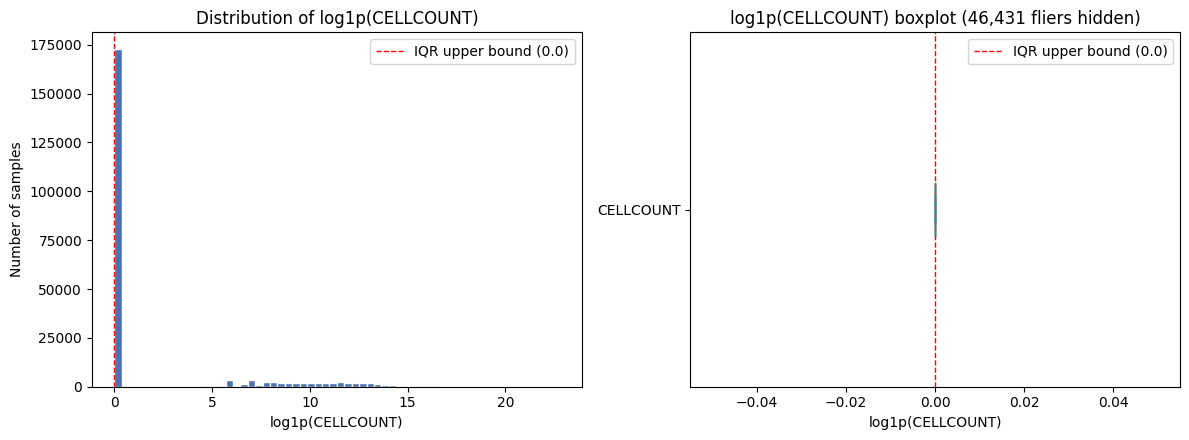

In [12]:
print("CELLCOUNT stats:\n", habsos["CELLCOUNT"].describe())

log_cc = np.log1p(habsos["CELLCOUNT"])
q1, q3 = log_cc.quantile(0.25), log_cc.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_outliers = int((log_cc > upper).sum())
print(f"\nIQR outlier threshold (log1p scale): {upper:.2f} -> raw cells/L: {np.expm1(upper):,.0f}")
print(f"Rows above threshold: {n_outliers} ({100 * n_outliers / len(habsos):.2f}%)")

# CELLCOUNT ranges from 0 to ~7.7B, so a raw-scale boxplot is unreadable (median/IQR collapse to a
# sliver near zero). log1p keeps zeros well-defined (log1p(0) = 0) and makes the shape visible.
# Fliers are hidden (showfliers=False): with tens of thousands of points beyond the IQR bound,
# plotting each as a marker overplots into a solid black smear rather than a readable boxplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(log_cc, bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(upper, color="red", linestyle="--", linewidth=1, label=f"IQR upper bound ({upper:.1f})")
axes[0].set_xlabel("log1p(CELLCOUNT)")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Distribution of log1p(CELLCOUNT)")
axes[0].legend()

log_cc.plot(kind="box", vert=False, ax=axes[1], showfliers=False)
axes[1].axvline(upper, color="red", linestyle="--", linewidth=1, label=f"IQR upper bound ({upper:.1f})")
axes[1].set_xlabel("log1p(CELLCOUNT)")
axes[1].set_title(f"log1p(CELLCOUNT) boxplot ({n_outliers:,} fliers hidden)")
axes[1].legend()
plt.tight_layout()
plt.show()

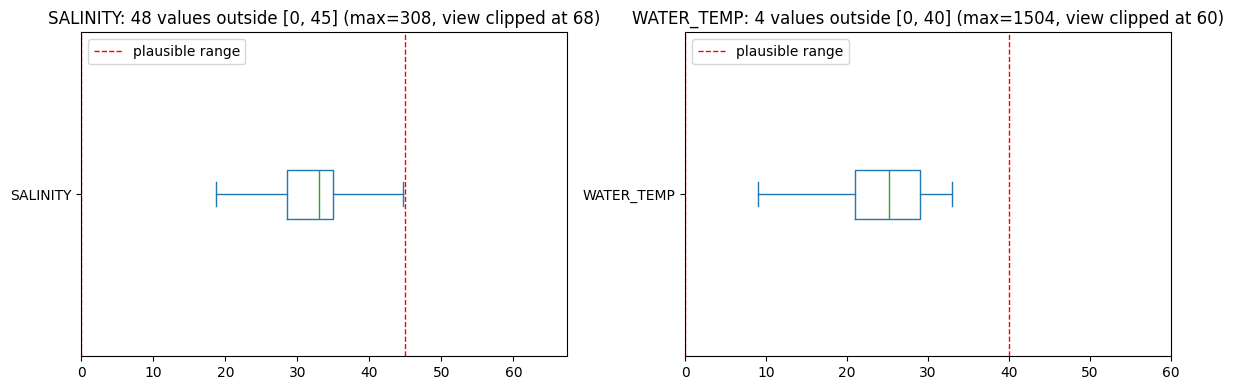

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, (lo, hi)) in zip(axes, {"SALINITY": (0, 45), "WATER_TEMP": (0, 40)}.items()):
    s = habsos[col].dropna()
    n_bad = int(((s < lo) | (s > hi)).sum())
    # Plotting every flier as a marker would overplot into a solid black smear given how many
    # points sit near (but within) the IQR bound, so fliers are hidden and the view is capped
    # just past the plausible range instead.
    view_max = hi * 1.5
    s.plot(kind="box", vert=False, ax=ax, showfliers=False)
    ax.axvline(lo, color="red", linestyle="--", linewidth=1, label="plausible range")
    ax.axvline(hi, color="red", linestyle="--", linewidth=1)
    ax.set_xlim(min(0, s.min()), view_max)
    ax.set_title(f"{col}: {n_bad} values outside [{lo}, {hi}] (max={s.max():.0f}, view clipped at {view_max:.0f})")
    ax.legend()
plt.tight_layout()
plt.show()